In [ ]:
# 3-2 수업 내용
1. Transformer
2. 파운데이션 모델
3. Transformer 기반, 사물인식 모델
4. Transformer 기반, 이미지 생성 멀티모달 모델
5. Transformer 기반, 그 밖에 멀티모달 모델

# 1. 수업 목표
- 아래 그림 기억나시지요? 벌써 Transformer 까지 도착했습니다.
  - MLP 시대 -> 딥러닝 시대(CNN) -> Transformer
  - 요즘 딥러닝을 한다고 하면 대부분 Transformer 구조를 택하는 시대입니다.
- 이번 주제는 Transformer / Foundation Model / Multi-Modal Foundation Model입니다.

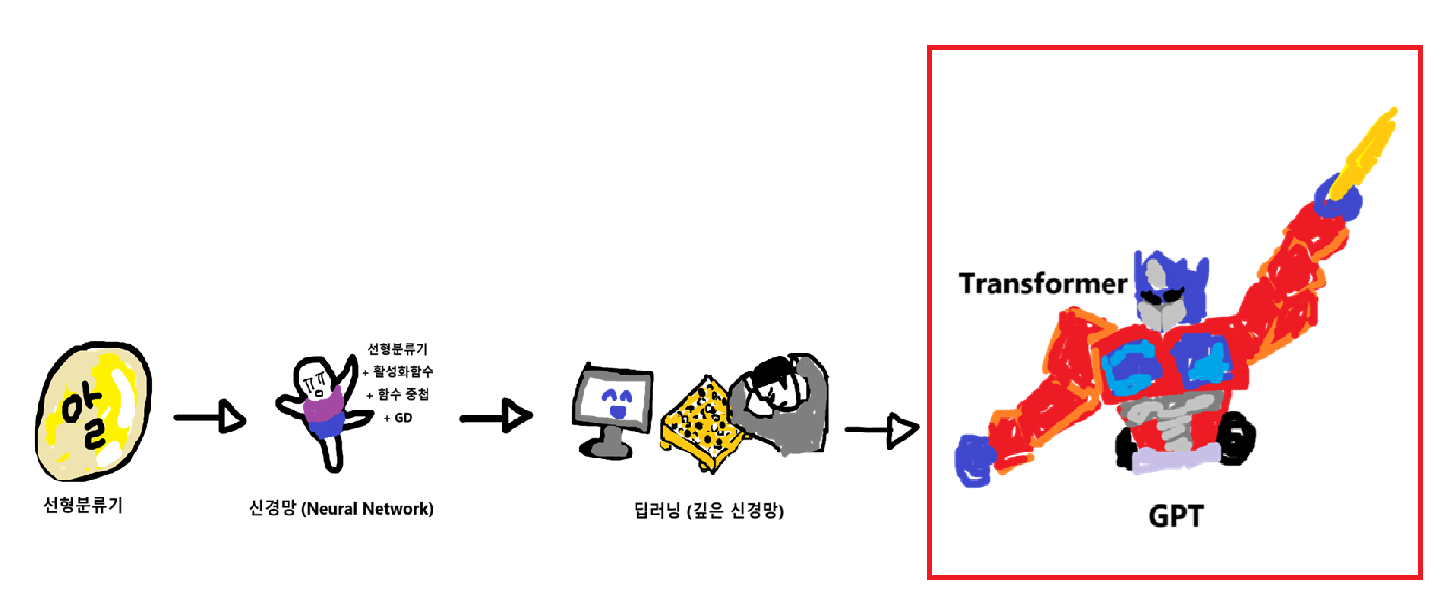

# 2. 시계열 모델(RNN) 부터 Transformer 까지

### 시계열 데이터와 시계열 모델

- 시간에 흐름 or 순서에 따라 기록된 자료를 **시계열데이터**라고 합니다.
  - 대표적으로 주식차트가 있습니다!
  - 그리고 음성데이터도 있습니다.
  - 그 중 문장도 시계열에 속합니다.
    왜냐면 왼쪽에서 오른쪽 순서로 보아야 의미가 있는 데이터이라서요.

- 시계열 **모델**은 뭘 할수있을까요?
  - 대표적으로 주가 예측을 할수 있습니다. 성능이 좋다면 미래를 예측하여 부자가 될수 있죠.
  - 기온도 예측할 수 있고, 차트로 그릴 수 있는 것은 예측이 가능합니다.
  - 문장에 다음 단어를 예측할 수 도 있어요.

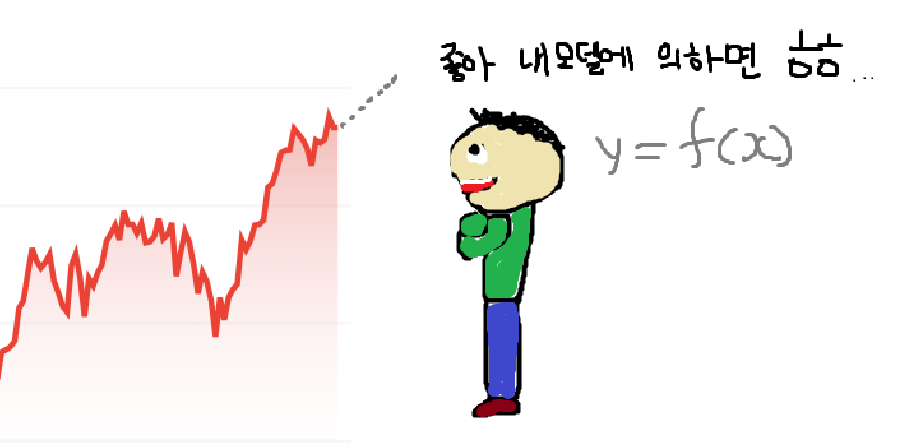

### RNN 모델로 시계열 모델이 시작됩니다.
- RNN(Recurrent Nueral Network)은 아래와 같은 구조를 갖습니다.
  - h는 히든레이어를 표현했습니다.
  

- 오른쪽 그림을 보시면 히든레이어 쪽에 뭔가 순환(Recurrent)하죠? 그래서 이름이 Recurrent NN 입니다.

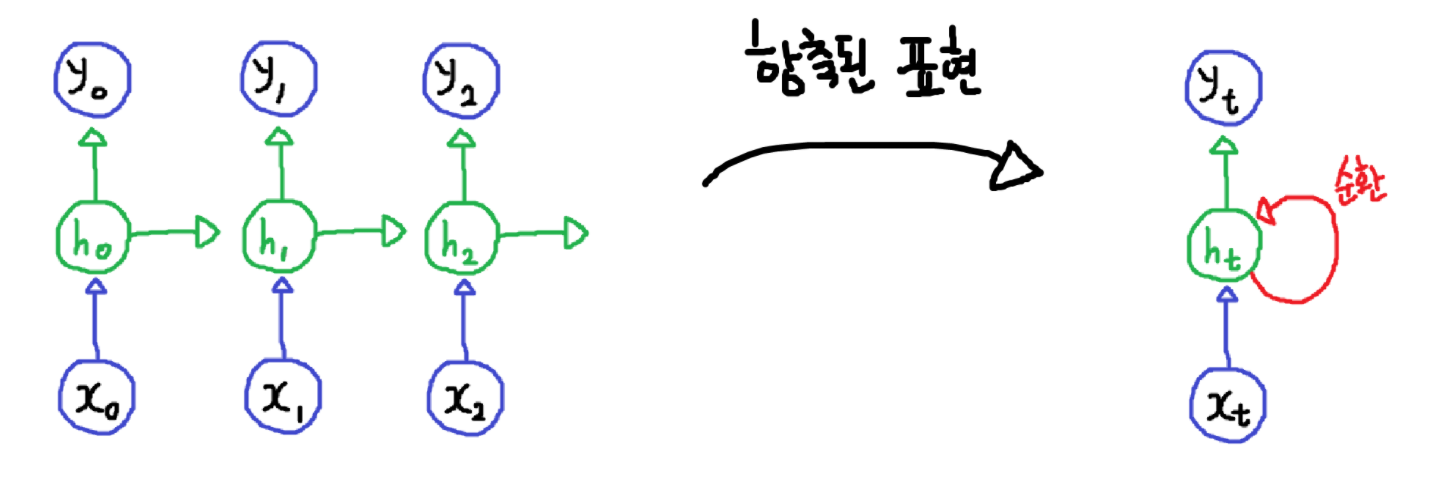

- 아래와 같이 표현됩니다~.

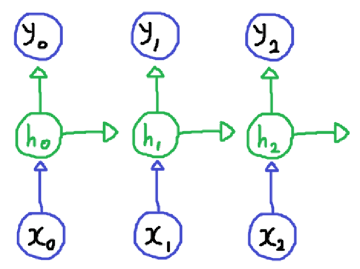

### RNN으로 데이터 학습 원리

- RNN은 이전 시점의 Hidden State의 출력값이, 다음 Hidden State 계산의 입력값으로 들어갑니다.
- RNN의 학습은 다음과 같이 이뤄집니다.
  - **이전 데이터들로 만들어진 정보(Hidden Layer 출력값)를, 다음 글자를 예측하는데 사용됩니다.**

  - 학습할때 입력데이터로 **['안', '녕, '하', '세, '요]** 를 넣어서 학습하겠다고 하겠습니다.

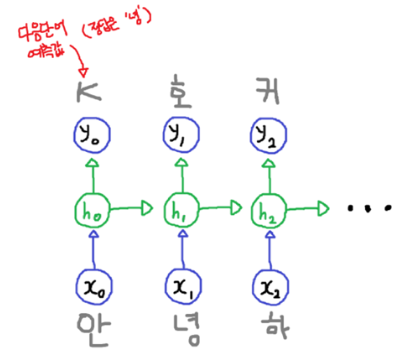

- 나름대로 '안' 다음 글자를 'K'로, 예측했고.. 이런식으로 각각 다음글자를 ['K', '호', '커'] 로 예측이 잘 안되었습니다.
- 이후에 GD를 통해, 오차율이 적도록 히든레이어 가중치 값이 업데이트 됩니다.
  - 그러면 점점 예측을 잘하게 될 것입니다.

- 아래 그림은 epoch을 반복해서 점점 똑똑해졌을 때.. 학습하고 있는 이미지입니다.
  - '녕' 까지는 예측이 잘 되었고, '!' 랑 'ㅋ' 는 오류가 있네요.

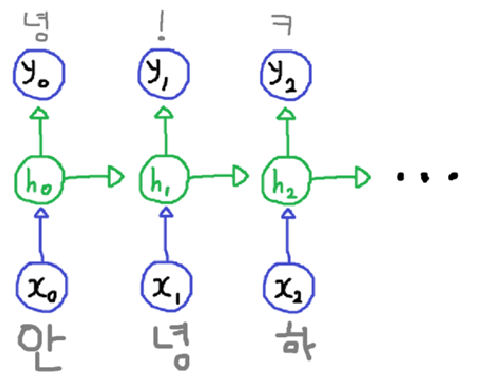

### RNN으로 추론 원리

- 학습이 완료되면 이제 추론에 사용됩니다.
  - 입력 데이터는 이거 하나면 됩니다. ['안'] 한글자요.
  - 그러면 다음 글자들이 연속적으로 예측할 수 있습니다.
  
- 아래 gif는 추론을 하는 예시입니다.

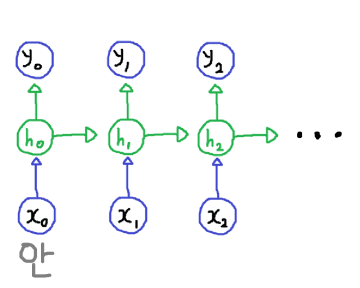

- 만약 추론할때 '안' 한글자가 아니라 '안녕요' 이후 다음문장을 예측하고 싶다면?
  - '안'을 입력으로 넣고, 고의적으로 출력 '녕'을 선택하고,
  - '녕'을 입력으로 넣고, 고의적으로 출력 '요'을 선택하고,
  - '요'을 입력으로 넣고, 이제부터는 RNN이 출력하는 것을 따르면 됩니다.



<br/>

- RNN 원리를 정리해보겠습니다.
  - RNN의 핵심 아이디어는 **이전에 사용했던 정보들을, 다음 단어를 예측하는데 사용** 하는 겁니다.
    - 예측해보고, GD로 점점 에러가적도록 파라미터를 업데이트 합니다.
    - 이후에 실제로 사용할때는 RNN이 추론한 글자들을 출력하면 됩니다.

### RNN의 단점


- Sequence가 길어질수록 초기 정보(Hidden State)들이 반영이 잘안됩니다.
  - 과거 기억을 잊게된다로 비유할 수 있겠습니다.

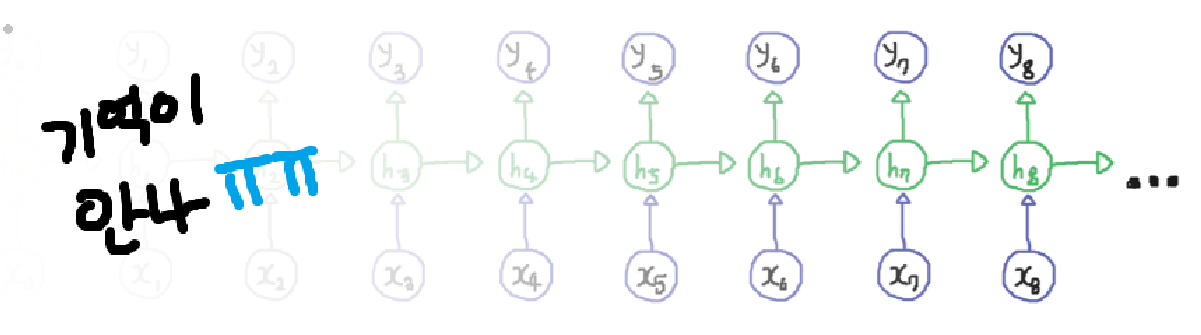

- 또한 Gradient Decent를 하는데 앞 부분은 학습이 잘 되는데, 뒷 부분은 학습이 잘 안됩니다.
  - GD를 위해 기울기 계산 (Backpropagation)을 합니다.
  - 그때 기울기 소실 (점점 0으로 수렴) 문제나, 기울기 폭발 (점점 거대한 값으로 폭발) 문제가 있습니다.

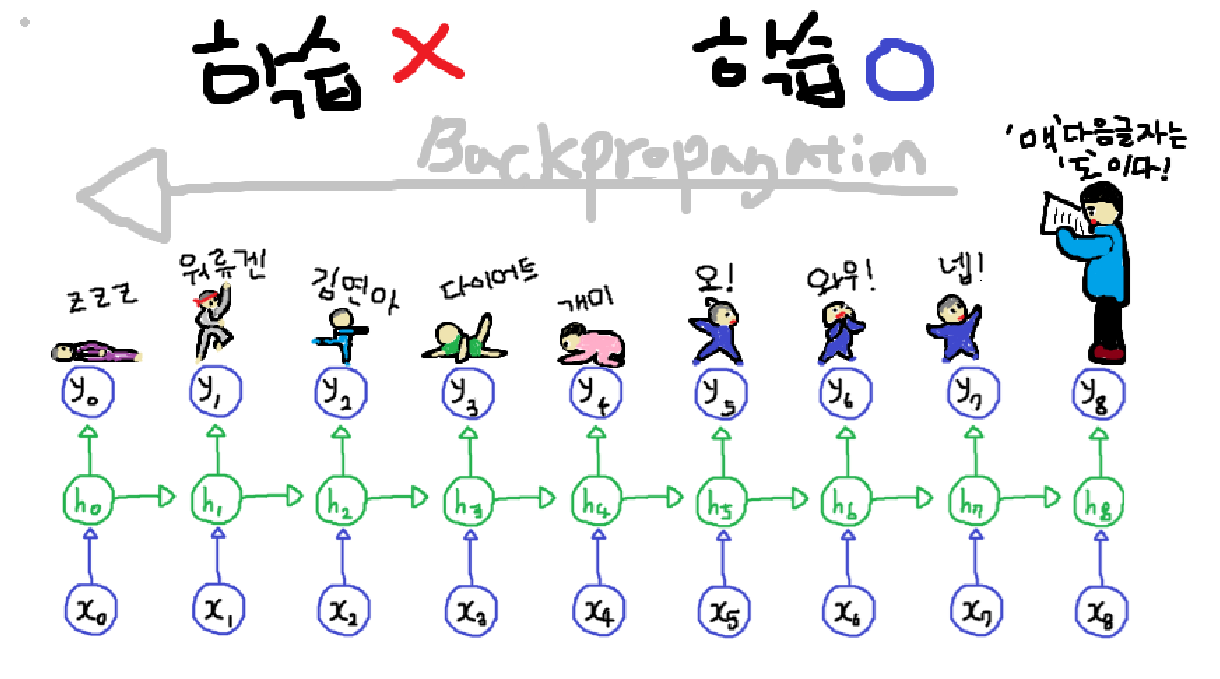

- 기울기 소실, 폭발문제 해결하기 위해 다른알고리즘들(LSTM)이 나왔지만, 여전히 오래전 정보를 잊어버리는 문제는 존재합니다.

## Transformer 모델에서 RNN 단점을 근본적으로 해결!


- 이러한 문제는 **Transformer 모델** 에서 근본적으로 해결되었습니다
- Transformer는 RNN처럼 과거 정보를, 다음 Layer로 전달해주는 방식을 버렸어요.
  - 참고로 RNN은 이전 Hidden Layer값이 모든 과거 정보를 내포하고 있었죠.
  - Transformer 모델은 입력값들의 정보들을 모두 참고하여 다음 Layer의 출력값을 만들어냅니다!
    - 장기기억 소실문제가 해결되었습니다.
    - 기울기 소실, 폭발 문제가 해결되었습니다.
    - 현대 딥러닝은 대부분 Transformer 모델을 기반으로 사용합니다




# 2. Attention과 Transformer 모델
- 시계열 모델(RNN 등) 한계를 극복하기 위해 탄생했습니다.
- Transformer는 Attention을 여러개 사용하는 모델입니다.
  - 일단 Attention이 무엇인지부터 보시죠.



### Attention
- 각 단어가 다른 단어들과 유사한 정도를 계산합니다.
- 이 유사성 정보들을 합쳐서, "문맥 표현 공간"의 벡터값을 계산합니다.

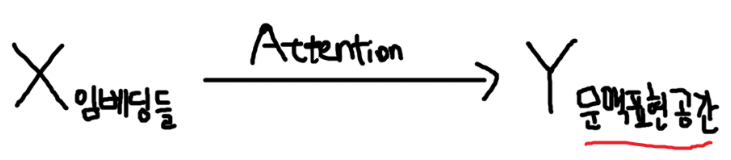

- 더 정확히 말하면 다음과 같습니다.
  - 그 동안 일반적인 선형계산에는 우리는 y = WX + b로 계산했죠?
    - 하나의 Weight 행렬을 사용합니다.
  - Attention을 계산할 때는 3개의 Weight 행렬을 사용합니다. 3개는 이름이 있습니다.
    - Query / Key / Value 행렬 입니다.
    - 이 Weight값은 학습에 대상이 됩니다~.

<br/>

- 그럼 아래 내용을 봅시다.
  - 복잡한 수식은 건강상 모자이크 처리 했습니다. ^^
  - 각 단어별 "의미공간"의 벡터값인 임베딩 벡터값을 구합니다.
  - 그리고 임베딩 벡터 값들을 각각 XW_query, XW_key, XW_value 값을 구합니다.
  - 이후에 Attention 수식에 대입하면 output을 구할 수 있습니다.
  - 이 output은 "문맥표현공간"의 벡터값이 됩니다.
    - 엄청난 고차원의 문맥 세계의 입주민이 되는겁니다.

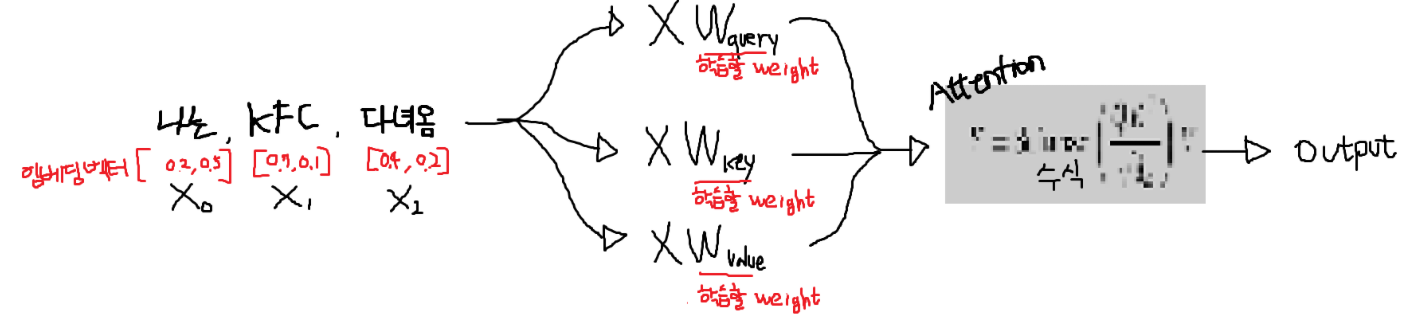

- 위 내용을 요약해보겠습니다.
- 먼저 아래와 같이 Q, K, V 는 각각의 Weight값을 곱한값입니다.
  - 임베딩 값에 선형변환을 한겁니다.

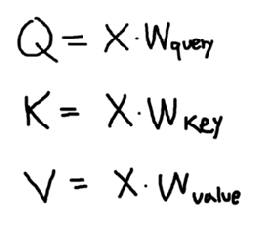

- 이후에 수식은 다음과 같이 요약할 수 있습니다.
  - Attention 함수는 아까 모자이크 했던 수식입니다.

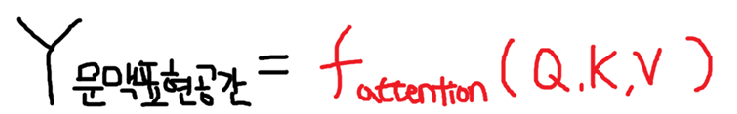

### Transformer 구조
- Transformer의구조는 아래와 같습니다.
  - 출처 : https://en.wikipedia.org/wiki/Transformer_(deep_learning_architecture)

- Tranformer는 Encoder들 + Decoder들 조합으로 구성되어있습니다.
  - Encoder, Decorder 모두 Attention과 MLP의 조합으로 구성되어있습니다.
  - Encoder : 문맥을 이해합니다.
  - Decoder : 입력 문장 정보를 이용해서, 출력 문장을 생성합니다.

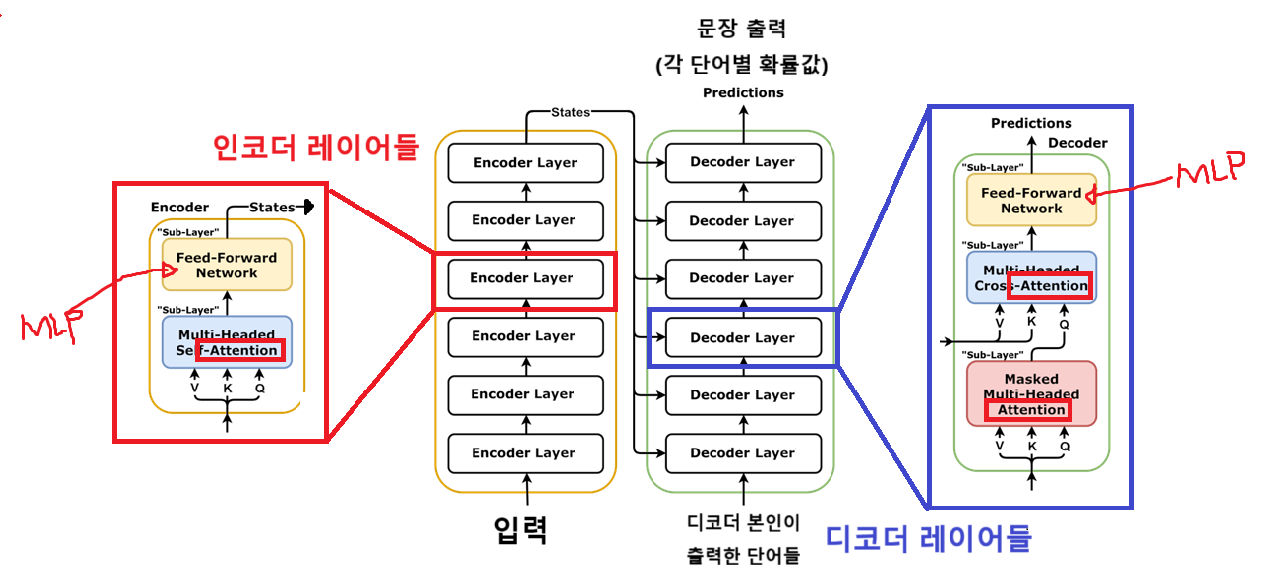

- 요약하면 다음과 같습니다.
  - 입력 문장 --> [Encoder × N개] --> 문맥 벡터
    - Encoder 여러개로 정교한 이해를 합니다.
  - 출력 문장 --> [Decoder × N개] --> 최종 문장 예측
    - Decoder 여러개로 점차 정교한 문장을 만들어냅니다.
    - 입력 : Decoder는 Encoder의 문맥 정보(State)들과 본인이 출력한 단어가 입력됩니다.
    - 출력 : Softmax 값으로, Vocabulary 들 각각 단어가 나올 확률들이 나옵니다.

# 3. Transformer 모델을 응용하여 만들 수 있는 것들

### 모달이란?
  - 인간이 정보를 인식할 수 있는 형태를 모달(Modality) 이라고 합니다.
    - Text, Image, Audio, .. 여러 Sensor 값들이 될 수 있습니다.
    - 여러 모달을 다루는 모델을, **멀티모달 모델**이라고 합니다. ex) 입력은 text , 결과는 image 인 모델

### 모달별 Transformer 활용 원리

- Text 모달
  - 문맥 전체를 더 잘 이해하도록 만들 수 있습니다.
  - 문맥에서 벗어나지 않는 문장을 만들어 낼수도 있습니다.

<br/>

- Image 모달
  - 이미지를 작은 단위로 잘라서 하나의 토큰처럼 취급합니다.
    - 이 단위를 패치(patch)라고 합니다.
  - 함께 어울릴 수 있는 패치들을 이해합니다.
    - 이러한 패치들의 조합을 확률 기반으로 선택하여, 자연스러운 이미지 생성할수도 있습니다. (DALL-E 원리)


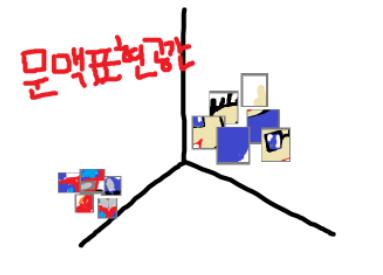


<br/>

- Text와 Image의 유사도 비교
  - Text의 토큰들과, Image의 패치들을 같은 "문맥표현공간"의 벡터 값으로 사용합니다.
  - Image 패치들이, 어떤 Text와 가장 관련이 있는지 알아낼 수 있습니다.
  - 이를 이용하여 사물 인식이 가능합니다.

  ex) CLIP 모델은 같은 의미 공간에 이미지와 text랑 일치하는 벡터 값을 뱉는다고 함

  ex) 트랜스포머 구조에서는 서로 다른 공간 벡터 값을 뱉고, attention으로 같은 공간 벡터을 얻는다고 함

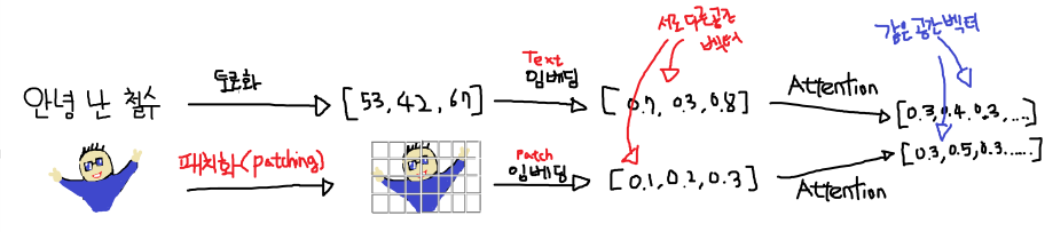

### 모달별 Transformer 활용 사례
  - Text를 입력하면 Image가 생성됩니다.
    - Text to Image 라고 합니다.
    - 예시 : "강아지 사진 만들어줘"
  - Text + Image를 동시에 입력하고, 결과를 받을 수 있습니다.
    - Image-Text to Text 라고 합니다.
    - 예시 : (사진을 주고), "이 사진은 낮이니 밤이니?" 라고 질문 가능합니다.
  - Text를 입력하면, 사람의 음성 Voice를 생성되도록 할 수 있습니다.
    - Text to Speech 라고 합니다.

<br/>

- 아래와 같이 **Transformer 모델이 발표된 이후, 정말 빠르게 Multi-Modal 시대가 되었습니다.**

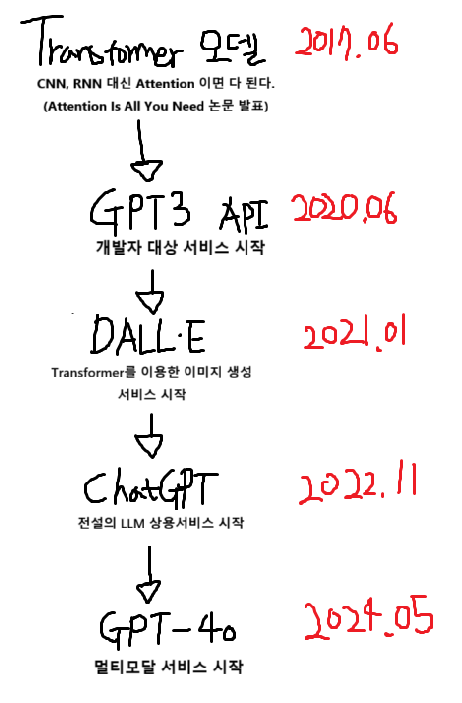

# 4. Foundation 모델

### 파운데이션 모델이란?
- Transformer 이후 시대에는 **Foundation 모델** 이라는 말이 생겼습니다.
- Foundation 모델은 '칭호' 같은 건데요. 다음 조건이 되면 됩니다.
  - **방대한** 범용 데이터로 학습하고
  - 다양한 목적에 맞게 **파인튜닝** 해서 사용 가능한
  - **대규모** 파라미터를 가진 모델

- 근데 방대한의 규모랑, 대규모의 범위는 정해진게 없습니다. ^^
  
<br/>

### 파운데이션 모델 종류 (대표적인 것 위주)
다음은 비공개 모델 입니다.
  - GPT 모델들 (OpenAI)
  - Claude 모델 (Anthropic)
  - Gemini 모델 (Google)

대표적인 공개 모델입니다. (오픈소스, 개인도 파인튜닝 가능)
 - LLaMA (Meta) : 공개 모델의 대표모델이라고 말할 수 있습니다.
 - Qwen (Alibaba) : Qwen3가 25년 4월에 출시되어 매우 인기 많아요.
 - gpt-oss (OpenAI) : 25년 8월 공개함, 연구자에게 매우 인기 많아요.

### 파운데이션 모델 살펴보기

- 허깅페이스에서 모델을 검색해봅시다.
- phi 라고 검색하면 phi-4 multimodal이 눈에 뜁니다.
  - 참고로 허깅페이스에서 멀티모달이라고 써있으면, Image, Text 모두 입력이 가능하다는 의미로 자주 쓰입니다.
  - Image, Text 모두 출력가능한 모델은 거의 없습니다.
  - 참고로 phi4 모델은 코랩 무료버전으로 돌리기 힘들어요. 유료 코랩 사용자만 써보세요.

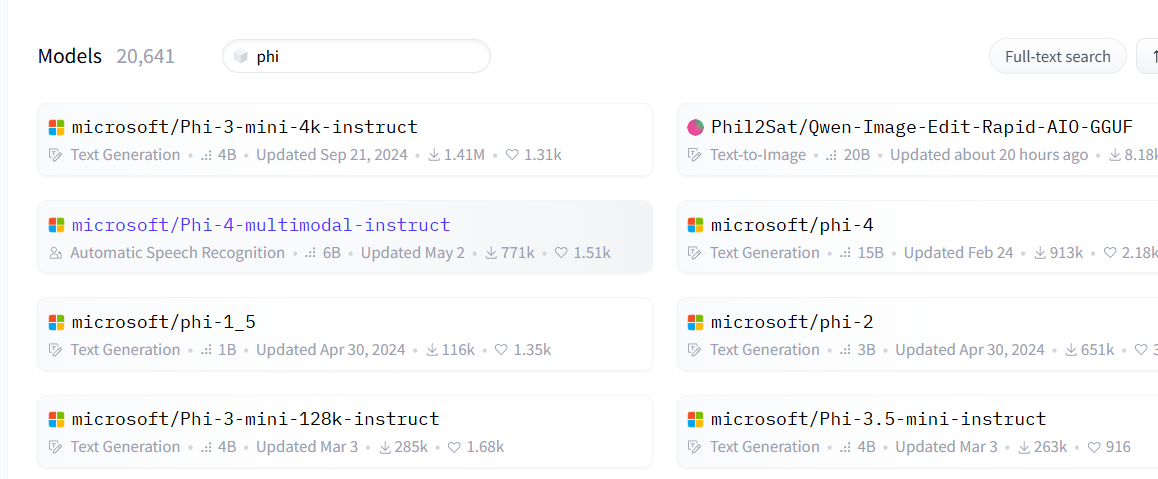

- qwen을 검색해봅시다.
  - Qwen-VL 이 눈에 뜁니다.
  - Vision, Language 라는 의미로 VL이라고 하며 이미지와 언어 동시에 입력받을 수 있는 멀티모달 모델입니다.
- 이렇게 모델마다 이름이 다르고, 멀티모달 모델과 아닌 모델 여러개가 동시에 존재합니다.

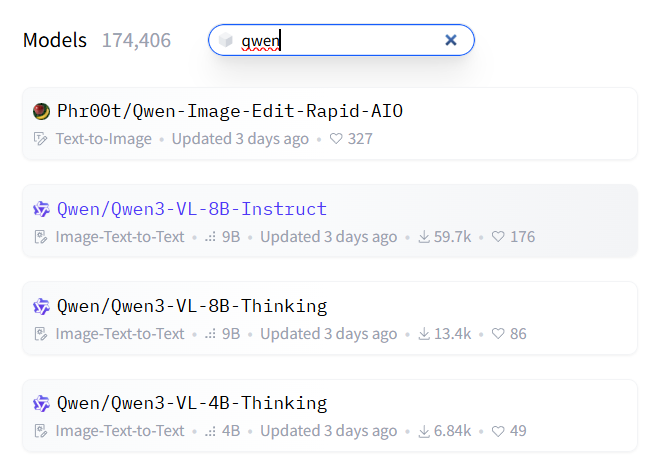

- 이미지 생성모델의 대표주자 중 하나인 Stable Diffusion도 살펴봅시다. ( 다른 하나는 DALL-E )
  - 로컬 PC 환경(또는 코랩)에서 이미지를 생성할 수 있습니다.

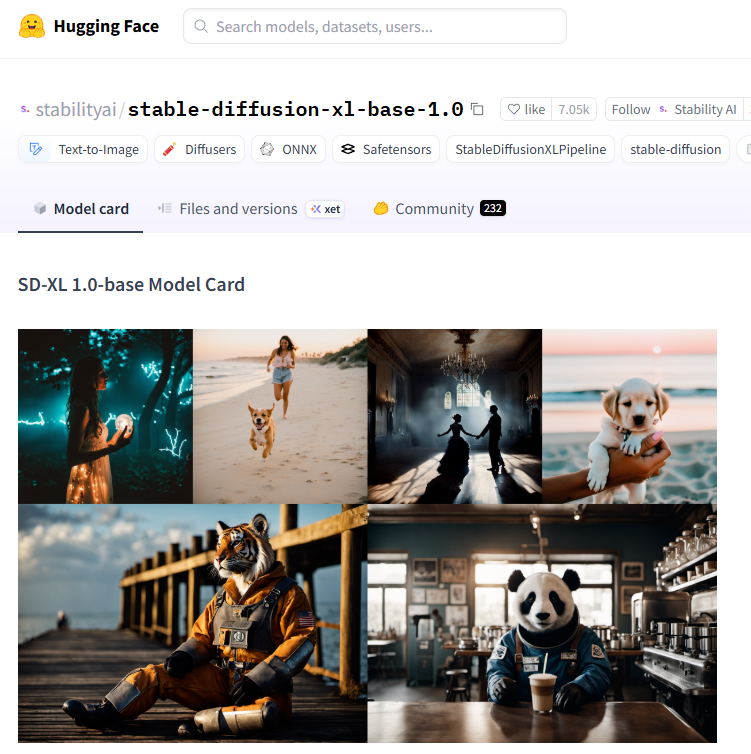

- 그 밖에 허깅페이스에 Models > Tasks 를 눌러서 더 많은 모델을 볼 수 있습니다.
  - Audio-Text-to-Text : 음성 or Text를 이해하는 멀티모달 모델
  - Text-To-Speech : 텍스트를 사람의 음성으로 읽어주는 모델

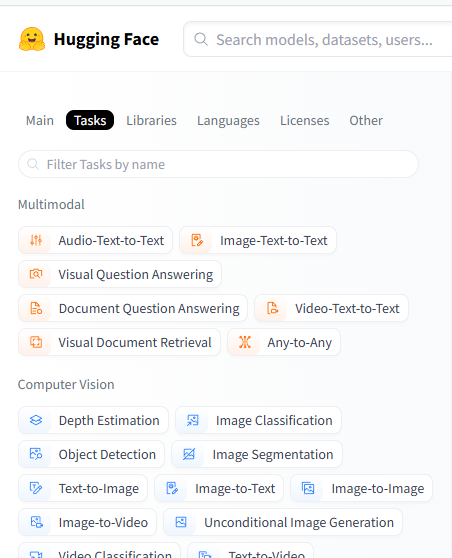

- 여러가지 테스트를 통해 나만의 AI Application을 제작할 수 있겠죠?

# 5. Transformer 기반, 사물인식 모델


- 이미지에서 미리 학습된 객체들을 탐지하는 모델을 돌려보겠습니다.
  - Object Detection 모델이라고 합니다.
- 이제 GPU를 켜주세요.

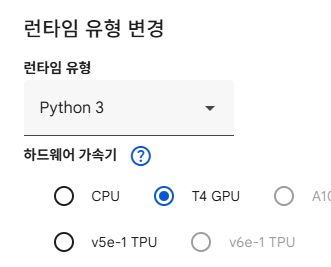

- 사용하는 모델은 Transformer로 만들어진 YOLOS 모델입니다.
  - CNN 기반 모델로 유명한 YOLO 모델은 (You Only Look Once) 이고요.
  - 지금 사용할 Transformer 기반 YOLOS 모델은 (You Only Look at One Sequence) 입니다.
    - 이름을 패러디한거예요.
    - hustvl/yolos-small (https://huggingface.co/hustvl/yolos-small)

  - 먼저 아래 명령어를 수행해서 공개 폰트를 다운로드받아주세요.
    - 이미지에 사물인식 결과를 표시하는데, 폰트가 너무 작아요.
    - 폰트사이즈를 키우려면 따로 폰트파일이 필요하다고 합니다. ^^;

In [1]:
!pip install torch==2.8.0 torchvision==0.23.0 --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.1 MB/s  0:12:130:00:0100:12
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 3.1 MB/s  0:01:350:00:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.2/889.2 MB 6.0 MB/s  0:03:15m0:00:0100:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 6.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 MB 6.4 MB/s  0:00:24m0:00:0100:01
  Attempting uninstall: triton
    Found existing installation: triton 3.6.0
    Uninstalling triton-3.6.0:
      Successfully uninstalled triton-3.6.0
  Attempting uninstall: nvidia-nccl-cu12━━━━━━━━ 0/5 [triton]
    Found existing installation: nvidia-nccl-cu12 2.28.95 [triton]
    Uninstalling nvidia-nccl-cu12-2.28.9:━━━ 0/5 [triton]
      Successfully uninstalled nvidia-nccl-cu12-2.28.9━━━━━━━━━━━━ 1/5 [nvidia-nccl-cu12]
  Attempting uninstall: nvidia-cudnn-cu12━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!wget https://github.com/google/fonts/raw/main/ofl/jejugothic/JejuGothic-Regular.ttf

--2026-08-19 10:55:12--  https://github.com/google/fonts/raw/main/ofl/jejugothic/JejuGothic-Regular.ttf
Resolving github.com (github.com)... 20.200.245.247
Connecting to github.com (github.com)|20.200.245.247|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google/fonts/main/ofl/jejugothic/JejuGothic-Regular.ttf [following]
--2026-08-19 10:55:12--  https://raw.githubusercontent.com/google/fonts/main/ofl/jejugothic/JejuGothic-Regular.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2479244 (2.4M) [application/octet-stream]
Saving to: ‘JejuGothic-Regular.ttf.1’

JejuGothic-Regular. 100%[===================>]   2.36M   243KB/s    in 10s     

2026-08-19 10:55:24 (241 KB/s) - ‘JejuGothic-Regular.

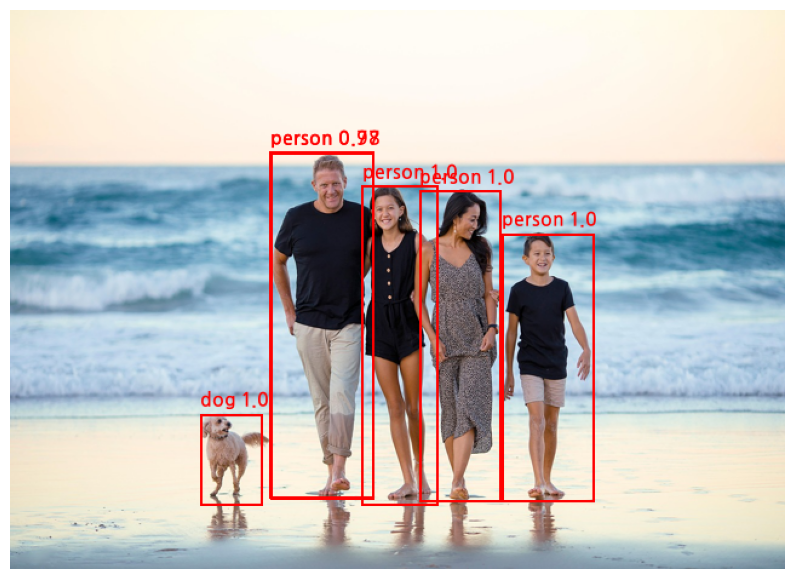

In [3]:
from transformers import YolosImageProcessor, YolosForObjectDetection
import requests
import torch
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# 이미지 로드 후 전처리
url = 'https://cdn.pixabay.com/photo/2021/07/09/02/29/family-6398107_1280.jpg'
image = Image.open(requests.get(url, stream=True).raw)
image = image.resize((640, 462))

# 전처리기, 모델 로드
feature_extractor = YolosImageProcessor.from_pretrained('hustvl/yolos-small')
model = YolosForObjectDetection.from_pretrained('hustvl/yolos-small')

# 입력 전처리
inputs = feature_extractor(images=image, return_tensors="pt")

# 모델추론
outputs = model(**inputs)

# 후처리
target_sizes = torch.tensor([image.size[::-1]])
results = feature_extractor.post_process_object_detection(
    outputs, threshold=0.7, target_sizes=target_sizes
)[0]

# 이미지에 바운딩박스 그리기
draw = ImageDraw.Draw(image)
font = ImageFont.truetype("JejuGothic-Regular.ttf", 16)

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    label_text = f"{model.config.id2label[label.item()]} {round(score.item(), 2)}"

    draw.rectangle(box, outline="red", width=2) # 빨간 사각형
    draw.text((box[0], box[1] - 20), label_text, fill="red", font=font) # 빨간색 글씨

# 결과 시각화
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")
plt.show()

# 6. Transformer 기반, 이미지 생성 멀티모달 모델
- Text to Image 모델로, 이미지를 생성해봅시다.
  - 입력은 Text이고, 출력은 Image 입니다. 두 가지 모달을 사용했으니 멀티모달 모델입니다~.
- 이미지 생성방법인 **Diffusion 알고리즘**은 다음과 같이 동작됩니다.
  - 학습 : 원본 이미지에 노이즈를 조금 추가하고 어디에 얼마나 노이즈를 추가했는지 예측합니다. 이를 반복합니다.
  - 추론 : 완전한 노이즈로 시작해서, 노이즈를 점점 제거하면서 복원하는 방법으로 이미지를 생성합니다.

- 이미지 출처 : https://developer.nvidia.com/blog/understanding-diffusion-models-an-essential-guide-for-aec-professionals/

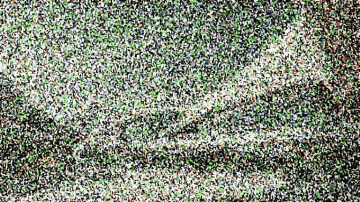

- 다음과 같은 모델을 사용했습니다.
  - "stabilityai/sd-turbo 모델입니다. (Stable Diffusion 2.1)
    - https://huggingface.co/stabilityai/sd-turbo
    - 적은 노이즈 제거 Step으로 빠르게 이미지 생성이 가능한 모델입니다.

In [4]:
!pip install diffusers accelerate safetensors

In [5]:
from diffusers import AutoPipelineForText2Image
import torch
import matplotlib.pyplot as plt

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sd-turbo", dtype=torch.float16, variant="fp16").to("cuda")

# 프롬프트 입력
prompt = "The puppy is eating a hamburger at McDonald's."

# 이미지 생성
image = pipe(prompt=prompt, num_inference_steps=2, guidance_scale=0.0).images[0]

# 이미지 출력
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

# 저장
image.save("result.png")


WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.7.0+cu126 with CUDA 1206 (you have 2.8.0+cu128)
    Python  3.11.12 (you have 3.11.12)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


RuntimeError: Failed to import diffusers.pipelines.auto_pipeline because of the following error (look up to see its traceback):
Failed to import diffusers.loaders.peft because of the following error (look up to see its traceback):
/opt/conda/lib/python3.11/site-packages/xformers/_C_flashattention3.so: undefined symbol: _ZN3c104cuda9SetDeviceEa

# 7. Transformer 기반, 그 밖에 멀티모달 모델
- 이미지와 텍스트를 입력하여 답변을 요청하는 모델입니다. (Image-Text to Text)
- 모델이름 : HuggingFaceTB/SmolVLM-Instruct
  - https://huggingface.co/HuggingFaceTB/SmolVLM-Instruct

- 오래걸립니다. **다운로드가 약 4.5G 입니다.** ( 5분 이상 소요 )
  - 프로젝트에 활용하시는데 도움됩니다. 인내를 가지고 기다려봅시다.
  - 참고로 코랩 다운로드는 여러분 PC의 인터넷 속도와 관련이 없습니다. 코랩 가상머신이 다운로드 받는거니 속도가 빨라요~!

- 아래 예제는 2개의 햄버거 사진과 프롬프트를 주고, 대답을 기다립니다.
  - 프롬프트 : "Can you explain the difference between the two images?

In [2]:
!pip install -U transformers

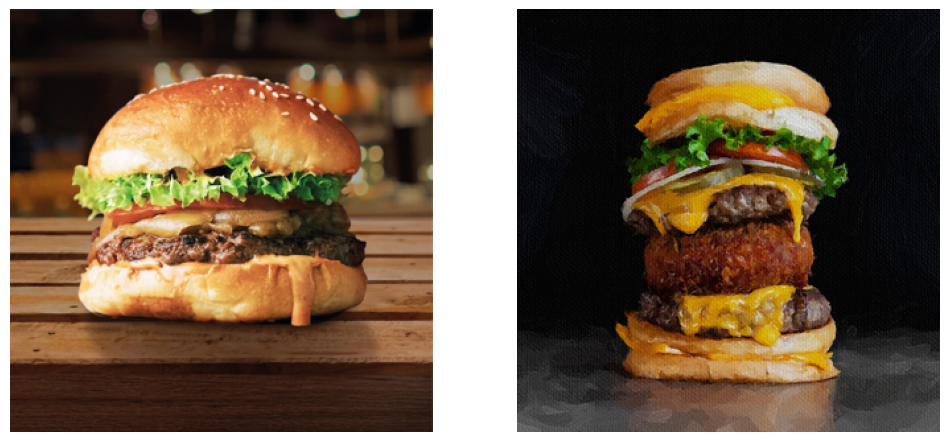

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/4.49G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

User:<row_1_col_1><row_1_col_2><row_1_col_3><row_1_col_4>
<row_2_col_1><row_2_col_2><row_2_col_3><row_2_col_4>
<row_3_col_1><row_3_col_2><row_3_col_3><row_3_col_4>
<row_4_col_1><row_4_col_2><row_4_col_3><row_4_col_4>

<global-img><row_1_col_1><row_1_col_2><row_1_col_3><row_1_col_4>
<row_2_col_1><row_2_col_2><row_2_col_3><row_2_col_4>
<row_3_col_1><row_3_col_2><row_3_col_3><row_3_col_4>
<row_4_col_1><row_4_col_2><row_4_col_3><row_4_col_4>

<global-img>Can you explain the difference between the two images?
Assistant: The first image shows a single burger on a wooden surface, while the second image shows multiple burgers stacked on top of each other.


In [6]:
import matplotlib.pyplot as plt
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText
from transformers.image_utils import load_image

# 사용할 장치 설정 (GPU가 있다면 GPU 사용)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 이미지 로드 & 출력
image1 = load_image(
    "https://cdn.pixabay.com/photo/2022/07/15/18/17/spicy-burger-7323694_1280.jpg"
)
image2 = load_image(
    "https://cdn.pixabay.com/photo/2020/01/28/12/52/burger-4799767_1280.jpg"
)

# 이미지 크기 조정
image1 = image1.resize((320, 320))
image2 = image2.resize((320, 320))

# 이미지 출력
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image2)
plt.axis("off")

plt.show()

# 프로세서 및 모델 초기화 (AutoModelForConditionalGeneration 사용)
processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-Instruct")

model = AutoModelForImageTextToText.from_pretrained(
    "HuggingFaceTB/SmolVLM-Instruct",
    torch_dtype=torch.bfloat16,   # 최신 transformers면 dtype= 도 가능
    _attn_implementation="eager",
).to(DEVICE)



# 메시지 생성 (이미지에 대한 설명을 요청)
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "image"},
            {
                "type": "text",
                "text": "Can you explain the difference between the two images?",
            },
        ],
    },
]

# 프롬프트 생성 및 입력 준비
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[image1, image2], return_tensors="pt")
inputs = inputs.to(DEVICE)

# 모델을 사용하여 텍스트 생성
generated_ids = model.generate(**inputs, max_new_tokens=500)
generated_texts = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True,
)

# 결과 출력
print(generated_texts[0])

# 8. 끝으로
  - Transformer 모델은 Attention들을 이용하여 만들어졌습니다.
  - 이는 Foundation 모델 시대를 열었고, 수 많은 응용으로 AI 시대가 되었습니다.
  - 거의 모든 SW에 AI를 활용할 수 있고, 더 나아가 Physical AI 개념까지 나오고 있습니다.
  - 오늘 수업을 통해 Transformer기반 모델을 다양하게 활용하셔서, 여러분의 프로젝트에 날개가 되길 바랍니다.

<br/>

### Easy 자료 (강사님 자료)
- AI를 처음 공부하는 분들을 위해 만들어져있습니다.
- 내용을 모두 이해해야합니다! **강사님의 도움을 적극적으로 받아주세요.**

### 실습 / 과제 자료 (업스테이지 자료)
- AI를 공부해본 경험자 위주로 만들어져있습니다.
- 퍼즐조각을 모은다는 생각으로 공부해주세요!. **GPT의 도움을 적극적으로 받아주세요.**

### 교수님 강의
- 국내 최고의 AI 교수님들의 강의가 시작됩니다.
- 최대한 내용을 이해해봅시다.
  